In [ ]:
import smtplib
from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart

def send_email():
    from_email = "906216606@qq.com"
    to_email = "shuhao.kang@tum.de"
    smtp_server = "smtp.qq.com"
    smtp_port = 465
    smtp_user = "906216606@qq.com"
    smtp_password = "obbihtenpioubbeh"  # 替换为正确授权码

    msg = MIMEMultipart()
    msg['From'] = from_email
    msg['To'] = to_email
    msg['Subject'] = "Test Email"

    body = "This is a test email sent from Python."
    msg.attach(MIMEText(body, 'plain'))

    try:
        with smtplib.SMTP_SSL(smtp_server, smtp_port, timeout=30) as server:
            server.login(smtp_user, smtp_password)  # 登录SMTP服务器
            server.sendmail(from_email, to_email, msg.as_string())  # 发送邮件
        print("Email sent successfully!")

    except smtplib.SMTPException as e:
        print(f"SMTP error occurred: {e}")

    except Exception as e:
        print(f"An unexpected error occurred: {e}")
    finally:
        try:
            server.quit()
        except Exception:
            pass  
send_email()

SMTP error occurred: (-1, b'\x00\x00\x00')


In [ ]:
import smtplib
from email.mime.text import MIMEText

message = MIMEText("这是一封测试电子邮件。")
message["From"] = "shkang233@gmail.com"
message["To"] = "ge27tor@mytum.de"
message["Subject"] = "测试电子邮件"

server= smtplib.SMTP("smtp.gmail.com", 465,timeout=100)
server.login("shkang233@gmail.com", "nkci jnby gcck qusb")
server.sendmail("shkang233@gmail.com", "ge27tor@mytum.de", message.as_string())

SMTPServerDisconnected: Connection unexpectedly closed

In [ ]:
# Copyright (c) Meta Platforms, Inc. and affiliates.

import argparse
import shutil
import zipfile
from pathlib import Path

import numpy as np
from tqdm.auto import tqdm

from ... import logger
from maploc.osm.tiling import TileManager
from maploc.osm.viz import GeoPlotter
from maploc.utils.geo import BoundaryBox, Projection
from maploc.utils.io import DATA_URL, download_file
from maploc.data.dataset import KittiDataModule
from maploc.data.utils import parse_gps_file

split_files = ["test1_files.txt", "test2_files.txt", "train_files.txt"]

gps_files = [f"sequence_{i:02}.txt" for i in [0, 1, 2, 4, 5, 6, 7, 8, 9, 10]]

def prepare_osm(
    data_dir,
    osm_path,
    output_path,
    tile_margin=512,
    ppm=2,
):
    all_latlon = []
    for gps_path in gps_files:
        all_latlon.append(parse_gps_file(gps_path)[0])
    if not all_latlon:
        raise ValueError(f"Cannot find any GPS file in {data_dir}.")
    all_latlon = np.stack(all_latlon)
    projection = Projection.from_points(all_latlon[0])
    all_xy = projection.project(all_latlon)
    bbox_map = BoundaryBox(all_xy.min(0), all_xy.max(0)) + tile_margin

    plotter = GeoPlotter()
    plotter.points(all_latlon, "red", name="GPS")
    plotter.bbox(projection.unproject(bbox_map), "blue", "tiling bounding box")
    plotter.fig.write_html(data_dir / "split_kitti.html")

    tile_manager = TileManager.from_bbox(
        projection,
        bbox_map,
        ppm,
        path=osm_path,
    )
    tile_manager.save(output_path)
    return tile_manager


def download(data_dir: Path):
    data_dir.mkdir(exist_ok=True, parents=True)
    this_dir = Path(__file__).parent

    seqs = set()
    for f in split_files:
        shutil.copy(this_dir / f, data_dir)
        with open(this_dir / f, "r") as fid:
            info = fid.read()
        for line in info.split("\n"):
            if line:
                seq = line.split()[0].split("/")[1][: -len("_sync")]
                seqs.add(seq)
    dates = {"_".join(s.split("_")[:3]) for s in seqs}
    logger.info("Downloading data for %d sequences in %d dates", len(seqs), len(dates))

    for seq in tqdm(seqs):
        logger.info("Working on %s.", seq)
        date = "_".join(seq.split("_")[:3])
        url = f"https://s3.eu-central-1.amazonaws.com/avg-kitti/raw_data/{seq}/{seq}_sync.zip"  # noqa E501
        seq_dir = data_dir / date / f"{seq}_sync"
        if seq_dir.exists():
            continue
        zip_path = download_file(url, data_dir)
        with zipfile.ZipFile(zip_path, "r") as z:
            z.extractall(data_dir)
        # Delete unused files to save space.
        for image_index in [0, 1, 3]:
            shutil.rmtree(seq_dir / f"image_0{image_index}")
        shutil.rmtree(seq_dir / "velodyne_points")
        Path(zip_path).unlink()

    for date in tqdm(dates):
        url = (
            f"https://s3.eu-central-1.amazonaws.com/avg-kitti/raw_data/{date}_calib.zip"
        )
        zip_path = download_file(url, data_dir)
        with zipfile.ZipFile(zip_path, "r") as z:
            z.extractall(data_dir)
        Path(zip_path).unlink()


if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument(
        "--data_dir", type=Path, default=Path(KittiDataModule.default_cfg["data_dir"])
    )
    parser.add_argument("--pixel_per_meter", type=int, default=2)
    parser.add_argument("--generate_tiles", action="store_true")
    args = parser.parse_args()

    args.data_dir.mkdir(exist_ok=True, parents=True)
    download(args.data_dir)

    tiles_path = args.data_dir / KittiDataModule.default_cfg["tiles_filename"]
    if args.generate_tiles:
        logger.info("Generating the map tiles.")
        osm_filename = "karlsruhe.osm"
        osm_path = args.data_dir / osm_filename
        if not osm_path.exists():
            logger.info("Downloading OSM raw data.")
            download_file(DATA_URL + f"/osm/{osm_filename}", osm_path)
        if not osm_path.exists():
            raise FileNotFoundError(f"No OSM data file at {osm_path}.")
        prepare_osm(args.data_dir, osm_path, tiles_path, ppm=args.pixel_per_meter)
        (args.data_dir / ".downloaded").touch()
    else:
        logger.info("Downloading pre-generated map tiles.")
        download_file(DATA_URL + "/tiles/kitti.pkl", tiles_path)


ImportError: attempted relative import with no known parent package

In [2]:
import sys

if ".." not in sys.path:
    sys.path.insert(0, "..")

In [21]:
print(sys.path)
sys.path.remove("D:\\GitHub\\geo-localization-with-point-clouds-and-openstreetmap")

['C:\\Program Files (x86)\\Eclipse\\Sumo\\tools', 'c:\\Users\\kangs\\anaconda3\\envs\\loc\\python39.zip', 'c:\\Users\\kangs\\anaconda3\\envs\\loc\\DLLs', 'c:\\Users\\kangs\\anaconda3\\envs\\loc\\lib', 'c:\\Users\\kangs\\anaconda3\\envs\\loc', '', 'c:\\Users\\kangs\\anaconda3\\envs\\loc\\lib\\site-packages', 'c:\\Users\\kangs\\anaconda3\\envs\\loc\\lib\\site-packages\\maploc-0.0.0-py3.9.egg', 'c:\\Users\\kangs\\anaconda3\\envs\\loc\\lib\\site-packages\\win32', 'c:\\Users\\kangs\\anaconda3\\envs\\loc\\lib\\site-packages\\win32\\lib', 'c:\\Users\\kangs\\anaconda3\\envs\\loc\\lib\\site-packages\\Pythonwin', 'c:\\Users\\kangs\\anaconda3\\envs\\loc\\lib\\site-packages\\setuptools\\_vendor', 'D:\\GitHub\\geo-localization-with-point-clouds-and-openstreetmap\\']


ValueError: list.remove(x): x not in list

In [2]:
print(1)

1


(1, 4541, 2)
(1, 4541, 2)
[[-192. -192.]
 [-192. -192.]
 [-192. -192.]
 ...
 [-128. -128.]
 [-128. -128.]
 [-128. -128.]] [[-128. -128.]
 [-128. -128.]
 [-128. -128.]
 ...
 [ -64.  -64.]
 [ -64.  -64.]
 [ -64.  -64.]]


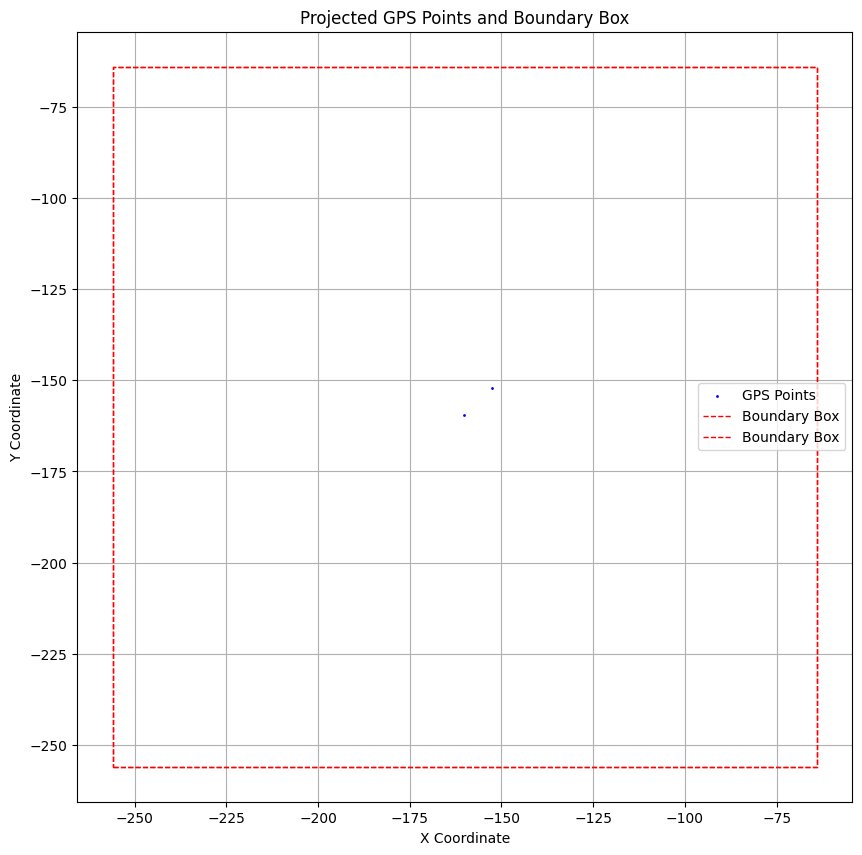

(1, 1101, 2)
(1, 1101, 2)
[[ 832. -640.]
 [ 832. -640.]
 [ 832. -640.]
 ...
 [-768.  512.]
 [-768.  512.]
 [-768.  512.]] [[ 896. -576.]
 [ 896. -576.]
 [ 896. -576.]
 ...
 [-704.  576.]
 [-704.  576.]
 [-704.  576.]]


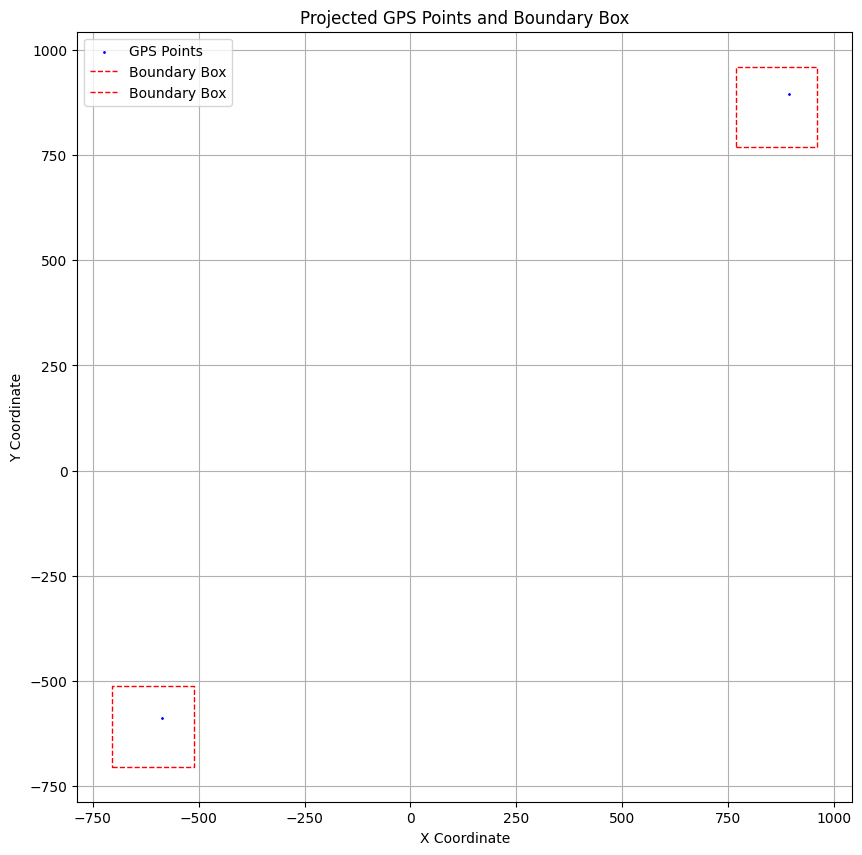

(1, 4661, 2)
(1, 4661, 2)
[[-512. -256.]
 [-512. -256.]
 [-512. -256.]
 ...
 [ 128.  384.]
 [ 128.  384.]
 [ 128.  384.]] [[-448. -192.]
 [-448. -192.]
 [-448. -192.]
 ...
 [ 192.  448.]
 [ 192.  448.]
 [ 192.  448.]]


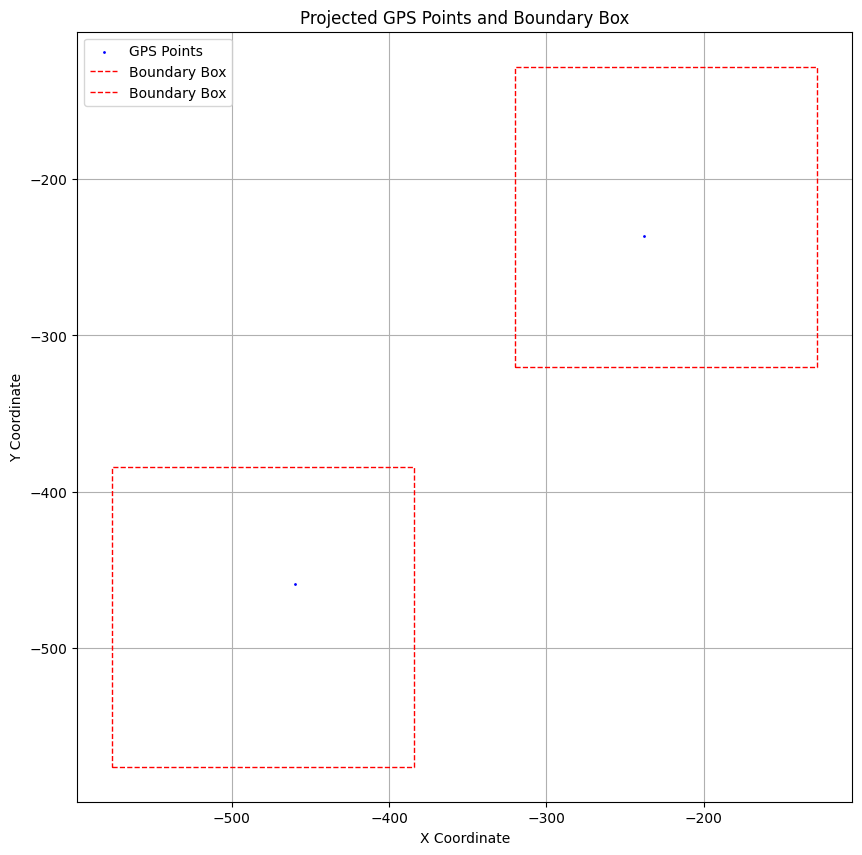

(1, 271, 2)
(1, 271, 2)
[[   0. -256.]
 [   0. -256.]
 [   0. -256.]
 [   0. -192.]
 [   0. -192.]
 [   0. -192.]
 [   0. -192.]
 [   0. -192.]
 [   0. -192.]
 [   0. -192.]
 [   0. -192.]
 [   0. -192.]
 [   0. -192.]
 [   0. -192.]
 [   0. -192.]
 [   0. -192.]
 [   0. -192.]
 [   0. -192.]
 [   0. -192.]
 [   0. -192.]
 [   0. -192.]
 [   0. -192.]
 [   0. -192.]
 [   0. -192.]
 [   0. -192.]
 [   0. -192.]
 [   0. -192.]
 [   0. -192.]
 [   0. -192.]
 [   0. -192.]
 [   0. -192.]
 [   0. -192.]
 [   0. -192.]
 [   0. -192.]
 [   0. -192.]
 [   0. -192.]
 [   0. -192.]
 [   0. -192.]
 [   0. -192.]
 [   0. -192.]
 [   0. -192.]
 [   0. -192.]
 [   0. -192.]
 [   0. -192.]
 [   0. -192.]
 [   0. -192.]
 [   0. -192.]
 [   0. -192.]
 [   0. -192.]
 [   0. -192.]
 [   0. -128.]
 [   0. -128.]
 [   0. -128.]
 [   0. -128.]
 [   0. -128.]
 [   0. -128.]
 [   0. -128.]
 [   0. -128.]
 [   0. -128.]
 [   0. -128.]
 [   0. -128.]
 [   0. -128.]
 [   0. -128.]
 [   0. -128.]
 [   0. -128.]
 

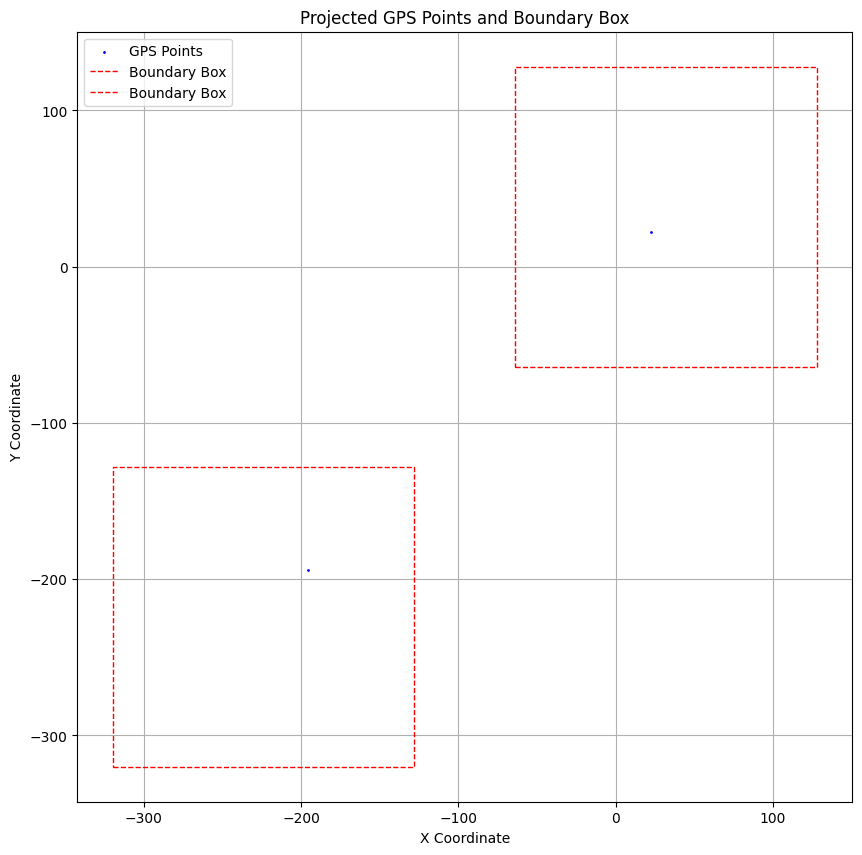

(1, 2761, 2)
(1, 2761, 2)
[[   0. -192.]
 [   0. -192.]
 [   0. -192.]
 ...
 [ -64.  192.]
 [ -64.  192.]
 [ -64.  192.]] [[  64. -128.]
 [  64. -128.]
 [  64. -128.]
 ...
 [  -0.  256.]
 [  -0.  256.]
 [  -0.  256.]]


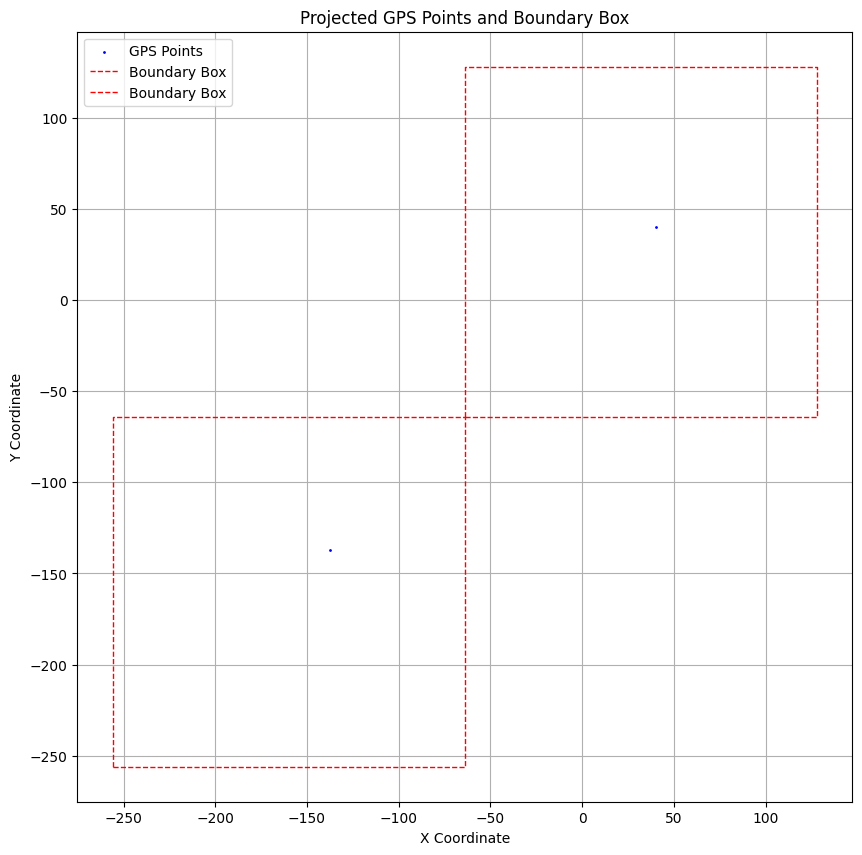

(1, 1101, 2)
(1, 1101, 2)
[[  64.    0.]
 [  64.    0.]
 [  64.    0.]
 ...
 [-256.  -64.]
 [-256.  -64.]
 [-256.  -64.]] [[ 128.   64.]
 [ 128.   64.]
 [ 128.   64.]
 ...
 [-192.   -0.]
 [-192.   -0.]
 [-192.   -0.]]


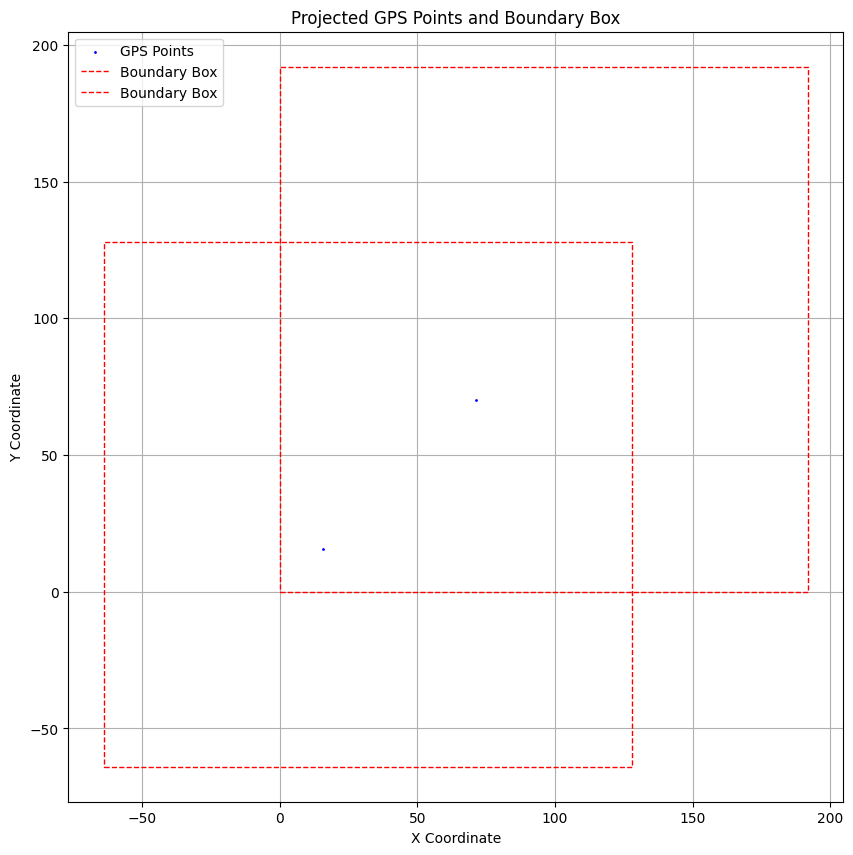

(1, 1101, 2)
(1, 1101, 2)
[[ -64. -128.]
 [ -64. -128.]
 [ -64. -128.]
 ...
 [ -64. -128.]
 [ -64. -128.]
 [ -64. -128.]] [[ -0. -64.]
 [ -0. -64.]
 [ -0. -64.]
 ...
 [ -0. -64.]
 [ -0. -64.]
 [ -0. -64.]]


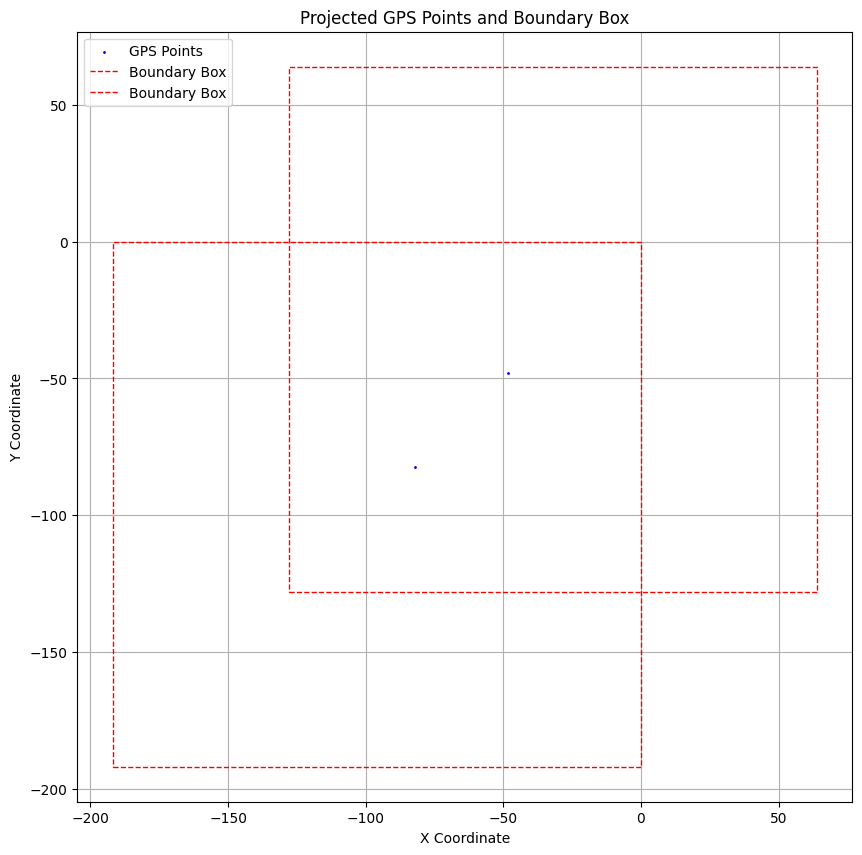

(1, 4071, 2)
(1, 4071, 2)
[[-256.  -64.]
 [-256.  -64.]
 [-256.  -64.]
 ...
 [  64.    0.]
 [  64.    0.]
 [  64.    0.]] [[-192.   -0.]
 [-192.   -0.]
 [-192.   -0.]
 ...
 [ 128.   64.]
 [ 128.   64.]
 [ 128.   64.]]


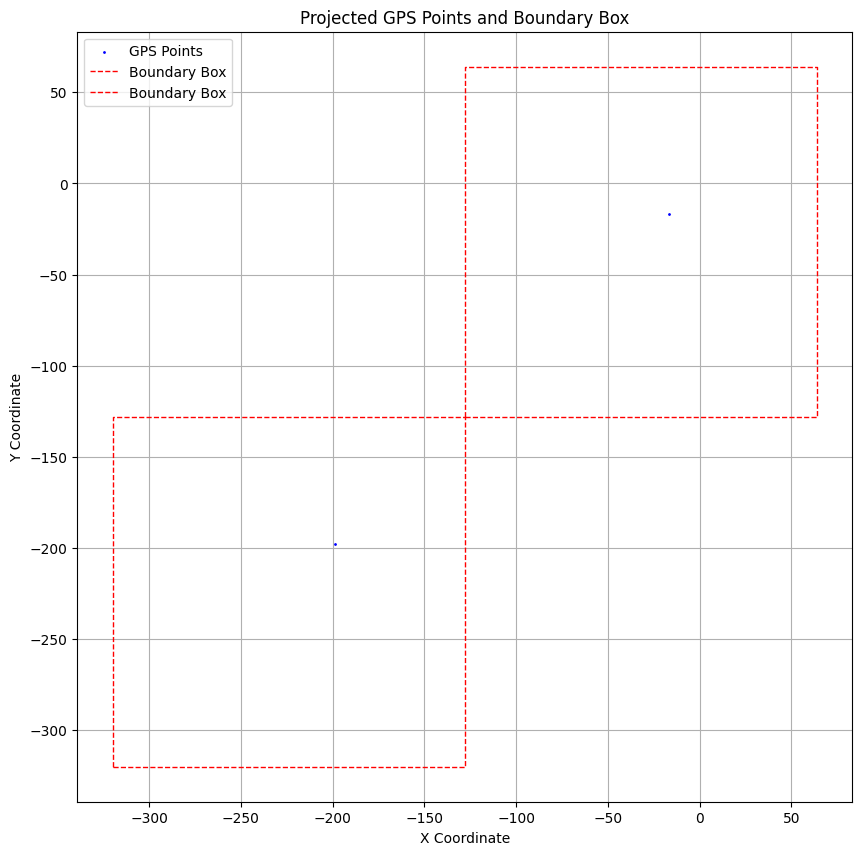

(1, 1591, 2)
(1, 1591, 2)
[[-256.  192.]
 [-256.  192.]
 [-256.  192.]
 ...
 [-192.  192.]
 [-192.  192.]
 [-192.  192.]] [[-192.  256.]
 [-192.  256.]
 [-192.  256.]
 ...
 [-128.  256.]
 [-128.  256.]
 [-128.  256.]]


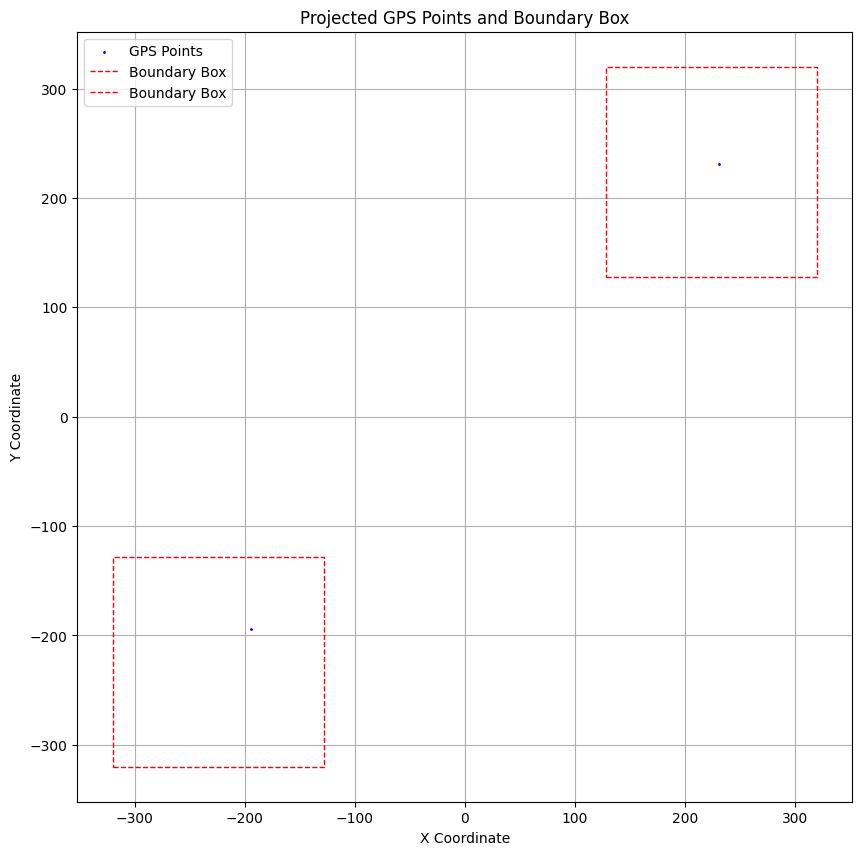

(1, 1201, 2)
(1, 1201, 2)
[[  64.  320.]
 [  64.  320.]
 [  64.  320.]
 ...
 [-128. -192.]
 [-128. -192.]
 [-128. -192.]] [[ 128.  384.]
 [ 128.  384.]
 [ 128.  384.]
 ...
 [ -64. -128.]
 [ -64. -128.]
 [ -64. -128.]]


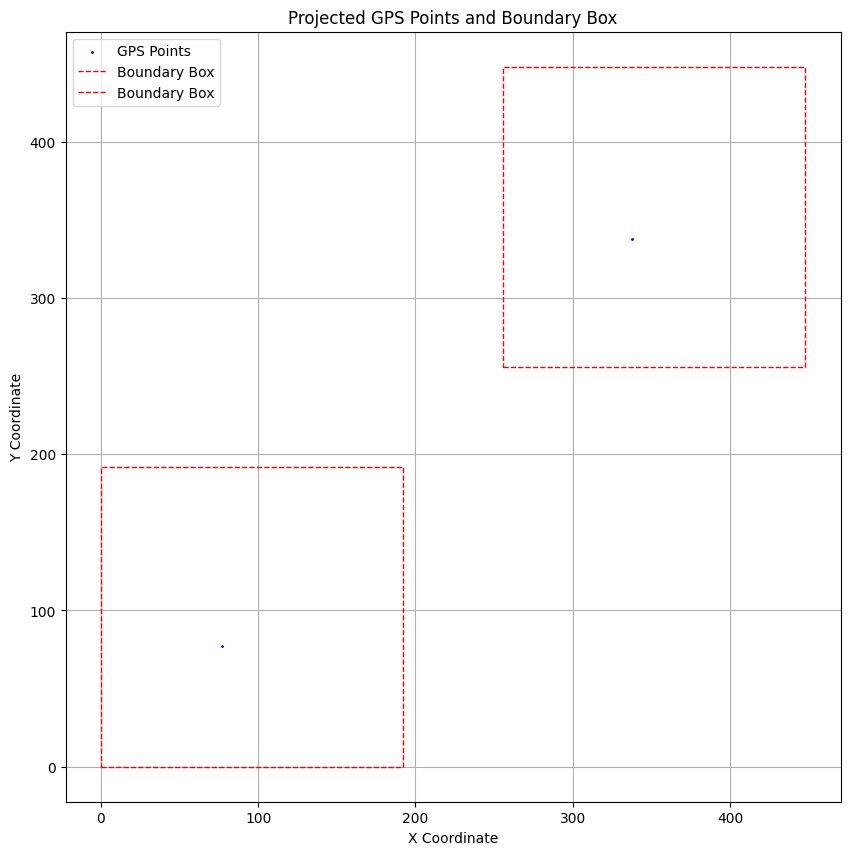

In [1]:
import argparse
import shutil
import zipfile
from pathlib import Path
import sys 
# sys.path.append('D:\\GitHub\\geo-localization-with-point-clouds-and-openstreetmap')
import numpy as np
from tqdm.auto import tqdm

from maploc.osm.tiling import TileManager
from maploc.utils.geo import BoundaryBox, Projection
from typing import List

def parse_gps_file(path: str):
    results = []
    data = np.load(path, allow_pickle=True).item()
    alt = data["alt"]
    lat = data["lat"]
    lon = data["lon"]

    for i in range(len(data['lat'])):
        results.append([lat[i], lon[i]])
    # print(results.shape)
    results = np.array(results)
    # print(results[0])
    return results

gps_files = [f"gps_sequence_{i:02}.npy" for i in [0, 1, 2, 4, 5, 6, 7, 8, 9, 10]]

data_dir = "./maploc/data/kitti/"
tile_margin = 64


for gps_path in gps_files:
    all_latlon = []
    # print(gps_path)
    all_latlon.append(parse_gps_file(data_dir+gps_path))
    # print(all_latlon[0:5])
    if not all_latlon:
        raise ValueError(f"Cannot find any GPS file in {data_dir}.")

    # print(all_latlon.shape)
    all_latlon = np.stack(all_latlon)
    print(all_latlon.shape) 
    projection = Projection.from_points(all_latlon)
    all_xy = projection.project(all_latlon)
    print(all_xy.shape)
    bbox_map = BoundaryBox(all_xy.min(0), all_xy.max(0))
    bbox_map_min = np.floor(all_xy.min(0) / 64) * 64 
    bbox_map_max = np.ceil(all_xy.max(0) / 64) * 64   

    # 创建扩展后的边界框
    expanded_bbox_map = BoundaryBox(bbox_map_min, bbox_map_max)
    print(expanded_bbox_map.min_, expanded_bbox_map.max_)
    bbox_map = expanded_bbox_map + tile_margin
    # print(all_xy.min(0), all_xy.max(0))

    import matplotlib.pyplot as plt
    from pathlib import Path

    plt.figure(figsize=(10, 10))
    plt.scatter(all_xy[:, 0], all_xy[:, 1], s=1, c='blue', label='GPS Points')

    # plt.scatter(all_latlon[:, 0], all_latlon[:, 1], s=1, c='blue', label='GPS Points')
    # 绘制边界框
    plt.plot(
        [bbox_map.min_[0], bbox_map.max_[0], bbox_map.max_[0], bbox_map.min_[0], bbox_map.min_[0]],
        [bbox_map.min_[1], bbox_map.min_[1], bbox_map.max_[1], bbox_map.max_[1], bbox_map.min_[1]],
        color='red', linestyle='--', linewidth=1, label='Boundary Box'
    )

    plt.xlabel("X Coordinate")
    plt.ylabel("Y Coordinate")
    plt.title("Projected GPS Points and Boundary Box")
    plt.legend()
    plt.grid(True)
    plt.show()

    # osm_path = Path("D:\\GitHub\\geo-localization-with-point-clouds-and-openstreetmap\\data_osm\\osm\\karlsruhe.osm")
    # ppm=2


    # tile_manager = TileManager.from_bbox(
    #         projection,
    #         bbox_map,
    #         ppm,
    #         path=osm_path,
    #     )
    # print(tile_manager)

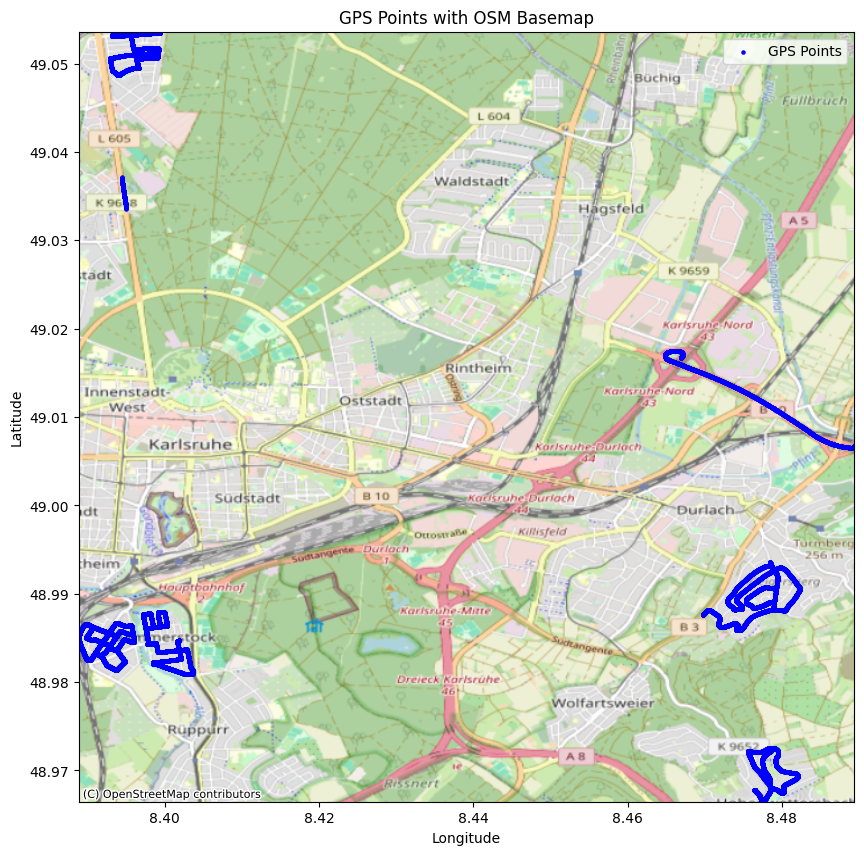

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import contextily as ctx

def parse_gps_file(path: str) -> np.ndarray:
    """
    解析GPS文件，返回经纬度数组
    """
    results = []
    with open(path, "r") as fid:
        for line in fid:
            lat, lon = map(float, line.strip().split(","))
            latlon = np.array([lat, lon])
            results.append(latlon)
    return np.stack(results)

# 加载GPS数据
gps_files = [f"sequence_{i:02}.txt" for i in [0, 1, 2, 4, 5, 6, 7, 8, 9, 10]]
data_dir = "./maploc/data/kitti/"

all_latlon = []
for gps_path in gps_files:
    all_latlon.append(parse_gps_file(data_dir + gps_path))

# 合并并转为numpy数组
all_latlon = np.vstack(all_latlon)

# 定义边界框的经纬度范围，用于加载OSM地图
lat_min, lon_min = all_latlon.min(axis=0)
lat_max, lon_max = all_latlon.max(axis=0)

# 可视化GPS点并叠加OSM底图
fig, ax = plt.subplots(figsize=(10, 10))

# 绘制GPS点
ax.scatter(all_latlon[:, 1], all_latlon[:, 0], s=5, c='blue', label='GPS Points')  # 注意 (lon, lat) 顺序

# 设置图形边界框
ax.set_xlim(lon_min, lon_max)
ax.set_ylim(lat_min, lat_max)

# 使用contextily叠加OSM底图，指定CRS为EPSG:4326（WGS 84经纬度坐标系）
ctx.add_basemap(ax, crs="EPSG:4326", source=ctx.providers.OpenStreetMap.Mapnik)

# 添加标题和图例
ax.set_title("GPS Points with OSM Basemap")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend()
plt.show()

